In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

workpath = '/content/drive/MyDrive/DigitalImageProcessing/'

Mounted at /content/drive


/tmp/ipython-input-5-2308951065.py:75: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = skimage.color.rgb2gray(imageio.imread(workpath + 'lung.png', pilmode='RGB'))


.............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................


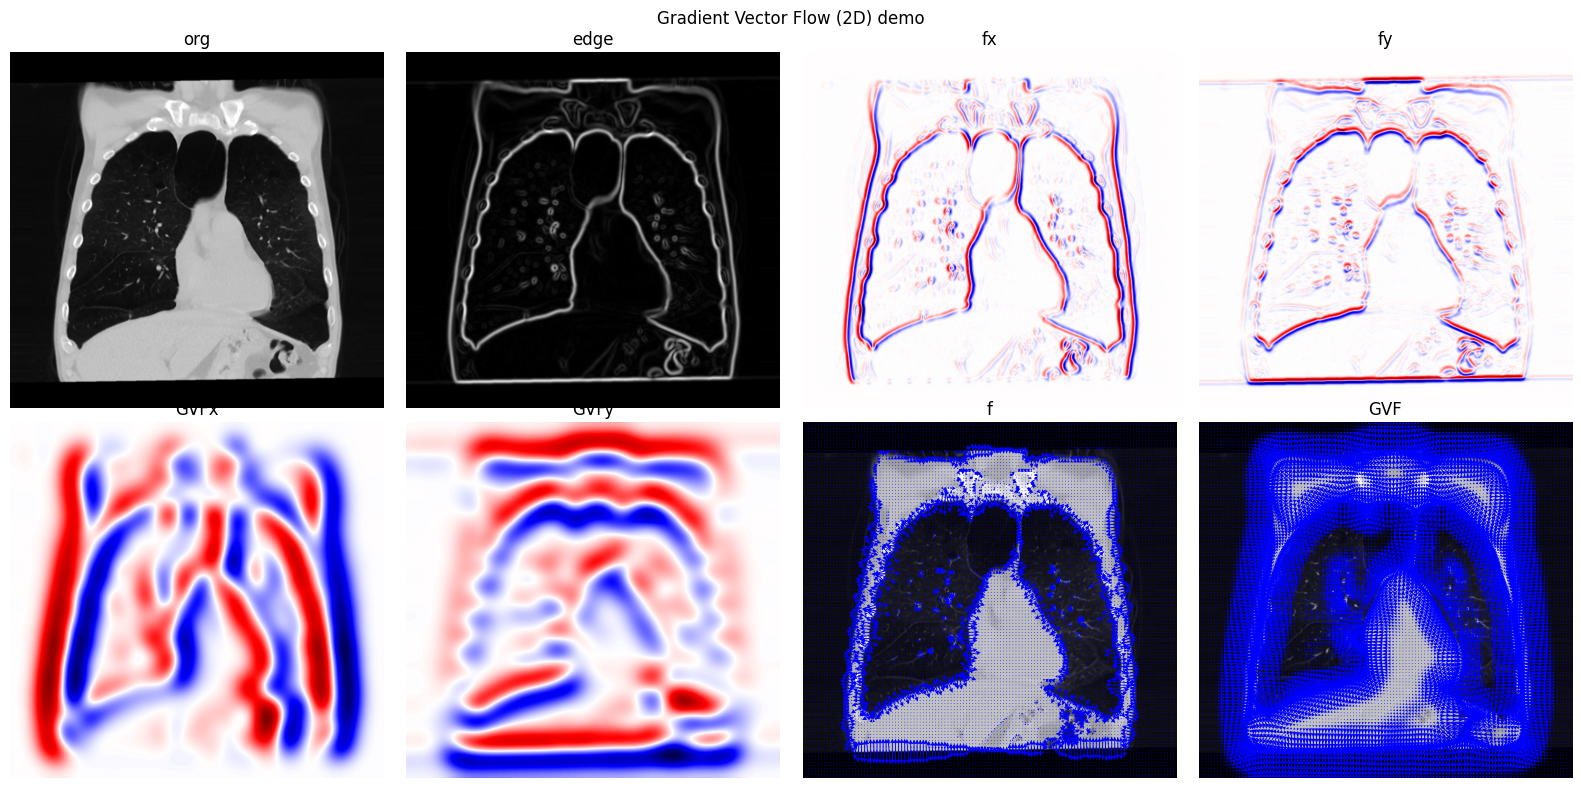

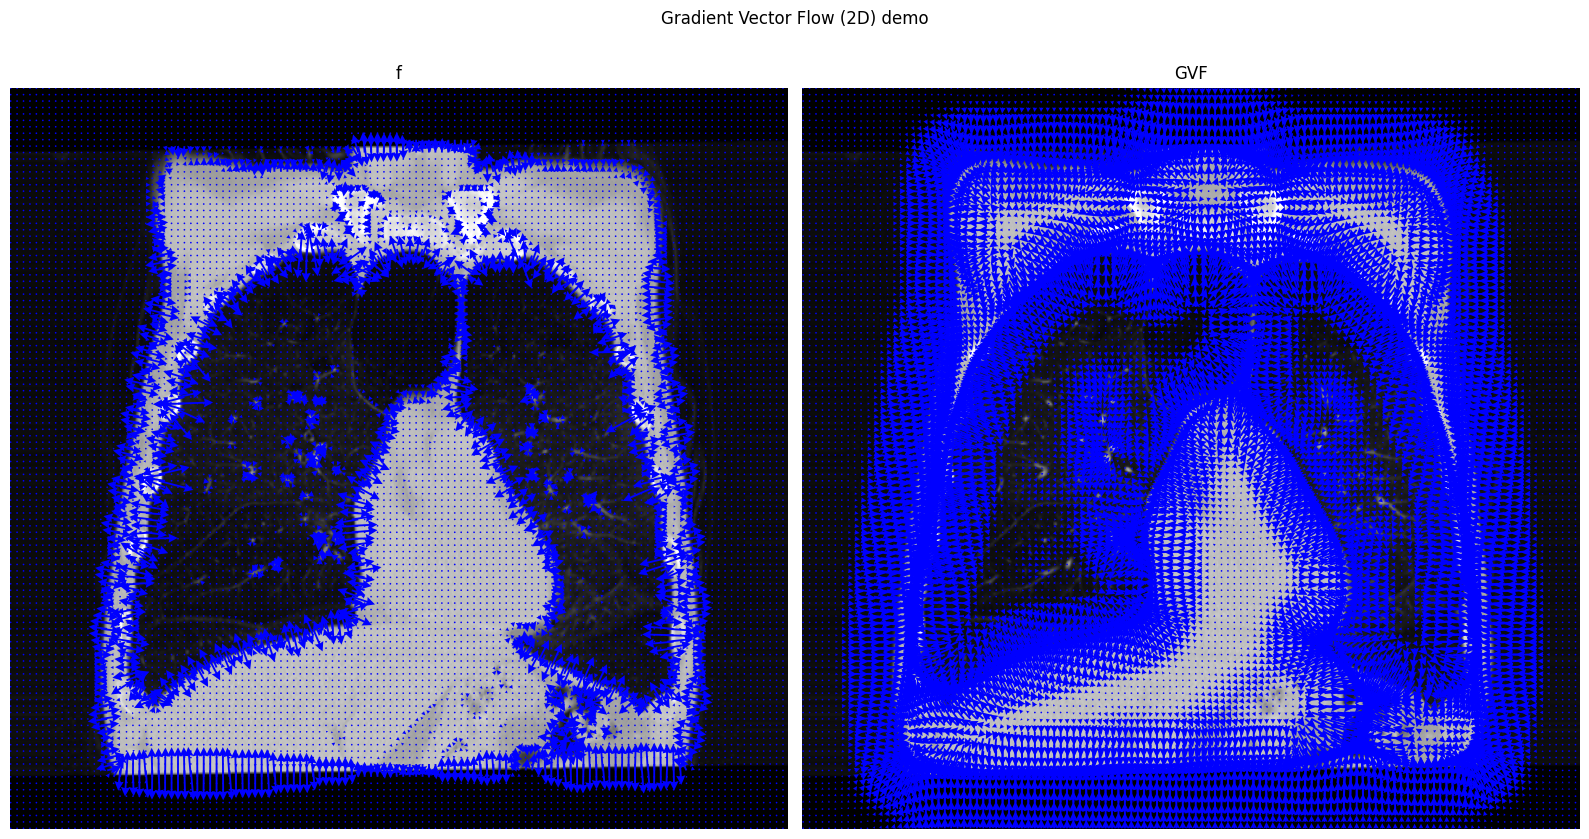

In [ ]:
# GVF(Gradient Vector Flow) of 2D image.
# reference:
# Chenyang Xu, et al. "Snakes, Shpes, and Gradient Vector Flow", IEEE TRANACTIONS ON IMAGE PROCESSING, VOL. 7, NO. 3, MARCH 1998

import sys
import imageio
import skimage.color
import skimage.data
import skimage.transform
try:
    import skimage.filters as skimage_filter
except:
    import skimage.filters as skimage_filter
import numpy as np
import matplotlib.pyplot as plt

def gradient_vector_flow(fx, fy, mu, dx=1.0, dy=1.0, verbose=True):
    u'''calc gradient vector flow of input gradient field fx, fy'''
    # calc some coefficients.
    b = fx**2.0 + fy**2.0
    c1, c2 = b*fx, b*fy
    # calc dt from scaling parameter r.
    r = 0.25 # (17) r < 1/4 required for convergence.
    dt = dx*dy/(r*mu)
    # max iteration
    N = int(max(1, np.sqrt(img.shape[0]*img.shape[1])))
    # initialize u(x, y), v(x, y) by the input.
    curr_u = fx
    curr_v = fy
    def laplacian(m):
        return np.hstack([m[:, 0:1], m[:, :-1]]) + np.hstack([m[:, 1:], m[:, -2:-1]]) \
                + np.vstack([m[0:1, :], m[:-1, :]]) + np.vstack([m[1:, :], m[-2:-1, :]]) \
                - 4*m
    for i in range(N):
        next_u = (1.0 - b*dt)*curr_u + r*laplacian(curr_u) + c1*dt
        next_v = (1.0 - b*dt)*curr_v + r*laplacian(curr_v) + c2*dt
        curr_u, curr_v = next_u, next_v
        if verbose:
            sys.stdout.write('.')
            sys.stdout.flush()
    if verbose:
        sys.stdout.write('\n')
    return curr_u, curr_v

def edge_map(img, sigma):
    blur = skimage.filters.gaussian(img, sigma)
    return skimage.filters.sobel(blur)

def gradient_field(im):
    im = skimage.filters.gaussian(im, 1.0)
    gradx = np.hstack([im[:, 1:], im[:, -2:-1]]) - np.hstack([im[:, 0:1], im[:, :-1]])
    grady = np.vstack([im[1:, :], im[-2:-1, :]]) - np.vstack([im[0:1, :], im[:-1, :]])
    return gradx, grady

def add_border(img, width):
    h, w = img.shape
    val = img[:, 0].mean() + img[:, -1].mean() + img[0, :].mean() + img[-1, :].mean()
    res = np.zeros((h + width*2, w + width*2), dtype=img.dtype) + val
    res[width:h+width, width:w+width] = img
    res[:width, :] = res[width, :][np.newaxis, :]
    res[:, :width] = res[:, width][:, np.newaxis]
    res[h+width:, :] = res[h+width-1, :][np.newaxis, :]
    res[:, w+width:] = res[:, w+width-1][:, np.newaxis]
    return res

if __name__=='__main__':
    # load image and preprocess
    if len(sys.argv) > 1:
        fn = sys.argv[1]
        img = skimage.color.rgb2gray(imageio.imread(workpath + 'Data/lung.png', pilmode='RGB'))
    else:
        img = skimage.color.rgb2gray(skimage.data.lena())
        img = skimage.transform.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    img = add_border(img, 32)
    edge = edge_map(img, sigma=2)

    # calc GVF
    fx, fy = gradient_field(edge)
    gx, gy = gradient_vector_flow(fx, fy, mu=1.0)

    # plot the results
    H, W = img.shape
    Y, X = np.meshgrid(range(0, H, 5), range(0, W, 5))
    def plot_vector_field(ax, vx, vy):
        scale = np.sqrt(np.max(vx**2+vy**2))*20.0
        ax.imshow(img, cmap='gray')
        # vy shold be inversed (top=+Y -> top=-Y)
        ax.quiver(X, Y, vx[Y, X], -vy[Y, X], scale=scale, color='blue', headwidth=5)
    def vmin(values): return -max(values.max(), -values.min())
    def vmax(values): return max(values.max(), -values.min())
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Gradient Vector Flow (2D) demo')
    ax = axs[0][0]; ax.imshow(img, cmap='gray'); ax.set_title('org');ax.set_axis_off()
    ax = axs[0][1]; ax.imshow(edge[:, :], cmap='gray'); ax.set_title('edge');ax.set_axis_off()
    ax = axs[0][2]; ax.imshow(fx, vmin=vmin(fx), vmax=vmax(fx), cmap='seismic'); ax.set_title('fx');ax.set_axis_off()
    ax = axs[0][3]; ax.imshow(fy, vmin=vmin(fx), vmax=vmax(fx), cmap='seismic'); ax.set_title('fy');ax.set_axis_off()
    ax = axs[1][0]; ax.imshow(gx, vmin=vmin(gx), vmax=vmax(gx), cmap='seismic'); ax.set_title('GVFx');ax.set_axis_off()
    ax = axs[1][1]; ax.imshow(gy, vmin=vmin(gy), vmax=vmax(gy), cmap='seismic'); ax.set_title('GVFy');ax.set_axis_off()
    ax = axs[1][2]; plot_vector_field(ax, fx, fy); ax.set_title('f');ax.set_axis_off()
    ax = axs[1][3]; plot_vector_field(ax, gx, gy); ax.set_title('GVF');ax.set_axis_off()
    fig.tight_layout()
    fig, axs = plt.subplots(1, 2, figsize=(16, 9))
    fig.suptitle('Gradient Vector Flow (2D) demo')
    ax = axs[0]; plot_vector_field(ax, fx, fy); ax.set_title('f');ax.set_axis_off()
    ax = axs[1]; plot_vector_field(ax, gx, gy); ax.set_title('GVF');ax.set_axis_off()
    fig.tight_layout()
    plt.show()
